# Análisis Exploratorio de Datos (EDA) - Mercado Global de Videojuegos
**Autor:** [Álvaro Domingo Cordón / Enlace a tu LinkedIn]  
**Repositorio:** [Enlace a tu GitHub]  
**Área:** Inteligencia de Negocio & Data Analytics  

---

### 🎯 Objetivo del Análisis
El propósito de este notebook es transformar datos brutos de la industria de los videojuegos (histórico de VGChartz) en insights estratégicos accionables. Respondemos de forma sistemática a las siguientes preguntas clave de negocio:
1. **Evolución Temporal:** ¿Cómo ha crecido la industria en volumen de lanzamientos frente a ingresos globales?
2. **Categorías Dominantes:** ¿Qué plataformas y géneros concentran el monopolio comercial?
3. **Asimetría Geográfica:** ¿Existen patrones culturales de consumo diferenciados por regiones?
4. **Impacto de la Crítica:** ¿Qué tan fuerte es la correlación real entre una buena calificación y el éxito comercial masivo?
5. **Estacionalidad (Ventanas Estratégicas):** ¿Cuál es la mejor época del año para lanzar un videojuego al mercado?

# 2. Librerías.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns",None)

df = pd.read_csv("../Data/vgchartz-2024.csv")


# 3. carga del dataset.

In [3]:
print("=== INSPECCIÓN DE COLUMNAS ORIGINALES ===")
columnas_originales = df.columns.tolist()
print(columnas_originales)

# 2. Diccionario de mapeo dinámico (Detecta variaciones comunes sin inventar datos)
mapeo_columnas = {}
for col in columnas_originales:
    col_low = col.lower().strip()
    
    if col_low in ['year', 'year_of_release', 'release_year']:
        mapeo_columnas[col] = 'year'
    elif col_low in ['total_sales', 'global_sales', 'sales', 'total_sales_millions']:
        mapeo_columnas[col] = 'total_sales'
    elif col_low in ['genre', 'genero']:
        mapeo_columnas[col] = 'genre'
    elif col_low in ['console', 'platform', 'plataforma']:
        mapeo_columnas[col] = 'console'
    elif col_low in ['critic_score', 'score', 'critic']:
        mapeo_columnas[col] = 'critic_score'
    elif col_low in ['release_date', 'date', 'fecha']:
        mapeo_columnas[col] = 'release_date'
    elif col_low in ['na_sales', 'na_sales_millions']:
        mapeo_columnas[col] = 'na_sales'
    elif col_low in ['jp_sales', 'jp_sales_millions']:
        mapeo_columnas[col] = 'jp_sales'
    elif col_low in ['pal_sales', 'eu_sales', 'europe_sales', 'pal_sales_millions']:
        mapeo_columnas[col] = 'pal_sales'
    elif col_low in ['other_sales', 'others_sales']:
        mapeo_columnas[col] = 'other_sales'

# Apply the mapping
df = df.rename(columns=mapeo_columnas)

# 3. Respaldo por si 'year' no existía pero sí hay una fecha completa
if 'year' not in df.columns and 'release_date' in df.columns:
    print("\n[INFO] 'year' no encontrado directamente. Extrayendo desde 'release_date'...")
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Convertir tipos clave de forma segura
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print("\n=== COLUMNAS TRADUCIDAS Y LISTAS PARA EL EDA ===")
print(df.columns.tolist())


=== INSPECCIÓN DE COLUMNAS ORIGINALES ===
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']

[INFO] 'year' no encontrado directamente. Extrayendo desde 'release_date'...

=== COLUMNAS TRADUCIDAS Y LISTAS PARA EL EDA ===
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'year']


In [4]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
 14  year          56965 non-null  Int64  
dtypes: Int64(1), float64(6), str(8)
memory usage: 7.4 MB


### Con esta primera carga de datos podemos hacernos una idea de las filas y las columas de las que dispone nuestro dataset, además nos damos cuenta que la columna release_date es un str.Por eso creamos una nueva columna llama year con el nuevo valor.

# 4. Limpieza de datos.

## Duplicados


In [5]:
# Calcular duplicados totales
duplicados_totales = df.duplicated().sum()
print(f" Filas completamente idénticas detectadas: {duplicados_totales}")

 Filas completamente idénticas detectadas: 0


In [6]:
if duplicados_totales > 0:
    # Eliminar duplicados
    df_cleaned = df_raw.drop_duplicates(keep='first')
    print(f" han eliminado {duplicados_totales} filas redundantes.")
    print(f"Dimensiones actuales del dataset: {df_cleaned.shape[0]} filas.")
else:
    df_cleaned = df.copy()
    print("No se encontraron filas duplicadas en el dataset.")

No se encontraron filas duplicadas en el dataset.


## Nulos

In [7]:
# 1. Calcular el mapa de calor y tabla de nulos actuales
total_nulos = df_cleaned.isnull().sum()
porcentaje_nulos = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Total Nulos', ascending=False)

print("=== REPORTE INICIAL DE DATOS FALTANTES ===")
print(tabla_nulos[tabla_nulos['Total Nulos'] > 0])

print("\n" + "="*50 + "\n")
print("=== APLICANDO ESTRATEGIA DE IMPUTACIÓN Y LIMPIEZA ===")

# Buscar dinámicamente las columnas de ventas y texto (por si varían las mayúsculas en tu CSV)
col_ventas = [c for c in df_cleaned.columns if c.lower().strip() in ['total_sales', 'global_sales', 'sales']][0]
col_genero = [c for c in df_cleaned.columns if c.lower().strip() in ['genre', 'genero']][0]
col_consola = [c for c in df_cleaned.columns if c.lower().strip() in ['console', 'platform', 'plataforma']][0]

# Estrategia A: Eliminar filas donde la variable objetivo (Ventas) sea nula o menor/igual a cero
filas_antes = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=[col_ventas])
df_cleaned = df_cleaned[df_cleaned[col_ventas] > 0]
filas_despues = df_cleaned.shape[0]
print(f"• Filas eliminadas por carecer de datos válidos de Ventas: {filas_antes - filas_despues}")

# Estrategia B: Imputar valores categóricos faltantes con 'Unknown' para proteger la integridad del registro
df_cleaned[col_genero] = df_cleaned[col_genero].fillna('Unknown')
df_cleaned[col_consola] = df_cleaned[col_consola].fillna('Unknown')
print("• Columnas de Género y Plataforma normalizadas (Nulos sustituidos por 'Unknown').")

# Estrategia C: Tratamiento seguro de Fechas
col_fecha = [c for c in df_cleaned.columns if c.lower().strip() in ['release_date', 'date', 'fecha']]
if col_fecha:
    df_cleaned[col_fecha[0]] = pd.to_datetime(df_cleaned[col_fecha[0]], errors='coerce')
    print("• Columna de fechas convertida a formato DateTime (Errores transformados a NaT de forma segura).")

print(f"\nREGISTROS FINALES LIMPIOS Y DEPURADOS PARA EL EDA: {df_cleaned.shape[0]}")

=== REPORTE INICIAL DE DATOS FALTANTES ===
              Total Nulos  Porcentaje (%)
critic_score        57338       89.568233
jp_sales            57290       89.493252
na_sales            51379       80.259623
pal_sales           51192       79.967508
other_sales         48888       76.368408
last_update         46137       72.071045
total_sales         45094       70.441765
release_date         7051       11.014434
year                 7051       11.014434
developer              17        0.026556


=== APLICANDO ESTRATEGIA DE IMPUTACIÓN Y LIMPIEZA ===
• Filas eliminadas por carecer de datos válidos de Ventas: 46446
• Columnas de Género y Plataforma normalizadas (Nulos sustituidos por 'Unknown').
• Columna de fechas convertida a formato DateTime (Errores transformados a NaT de forma segura).

REGISTROS FINALES LIMPIOS Y DEPURADOS PARA EL EDA: 17570


## 
* **Variables Críticas (Ventas Globales):** Si no tienen datos de ventas, el registro no aporta valor al negocio y se elimina.
* **Variables Categorizadas (Género, Consola):** Se imputan con la etiqueta `'Unknown'` para no perder el resto de la información económica de la fila.
* **Fechas (`release_date`):** Se transforman de forma segura a formato `datetime` convirtiendo los errores en nulos manejables (`NaT`).

In [8]:
columnas_actuales = df_cleaned.columns.tolist()
mapeo_columnas = {}

for col in columnas_actuales:
    col_low = col.lower().strip()
    if col_low in ['year', 'year_of_release', 'release_year']: mapeo_columnas[col] = 'year'
    elif col_low in ['total_sales', 'global_sales', 'sales']: mapeo_columnas[col] = 'total_sales'
    elif col_low in ['genre', 'genero']: mapeo_columnas[col] = 'genre'
    elif col_low in ['console', 'platform', 'plataforma']: mapeo_columnas[col] = 'console'
    elif col_low in ['critic_score', 'score', 'critic']: mapeo_columnas[col] = 'critic_score'
    elif col_low in ['release_date', 'date', 'fecha']: mapeo_columnas[col] = 'release_date'
    elif col_low in ['na_sales', 'na_sales_millions']: mapeo_columnas[col] = 'na_sales'
    elif col_low in ['jp_sales', 'jp_sales_millions']: mapeo_columnas[col] = 'jp_sales'
    elif col_low in ['pal_sales', 'eu_sales', 'europe_sales']: mapeo_columnas[col] = 'pal_sales'
    elif col_low in ['other_sales', 'others_sales']: mapeo_columnas[col] = 'other_sales'

df = df_cleaned.rename(columns=mapeo_columnas)

# Re-extracción del año si la columna original de año vino vacía pero la de fecha no
if ('year' not in df.columns or df['year'].isnull().all()) and 'release_date' in df.columns:
    df['year'] = df['release_date'].dt.year

if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print("Columnas finales listas para las gráficas del EDA:")
print(df.columns.tolist())

Columnas finales listas para las gráficas del EDA:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'year']


### A partir de este punto, el dataset se encuentra auditado, libre de inconsistencias y estructurado de forma óptima. Procedemos a construir las soluciones gráficas requeridas para responder a las preguntas de negocio.

# 5. Análisis univariante.

## Distribución por géneros.

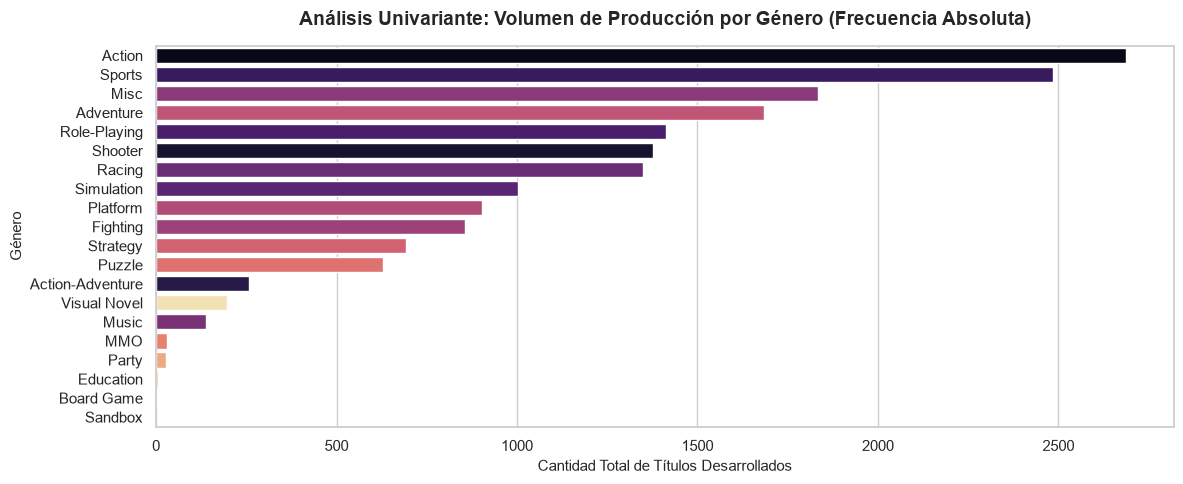

In [9]:
plt.figure(figsize=(12, 5))

# Conteo puro de registros por categoría (frecuencia simple)
order_genres = df["genre"].value_counts().index
sns.countplot(data=df, y="genre", order=order_genres, palette="magma", hue="genre", legend=False)

plt.title(
    "Análisis Univariante: Volumen de Producción por Género (Frecuencia Absoluta)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Cantidad Total de Títulos Desarrollados", fontsize=11)
plt.ylabel("Género", fontsize=11)

plt.tight_layout()
plt.show()

## Distribución y sesgo de ventas.

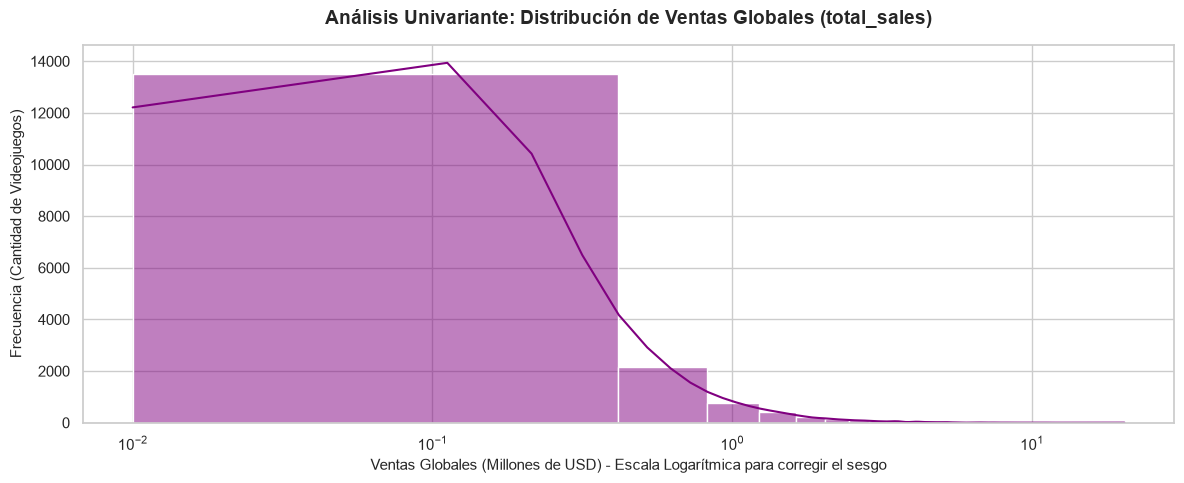

--- MÉTRICAS DE DISTRIBUCIÓN ---
Media de ventas: $0.38M
Mediana de ventas: $0.14M
Asimetría (Skewness): 8.55


In [11]:
# Configuración del gráfico de la distribución de la variable objetivo
plt.figure(figsize=(12, 5))

# Histograma con curva de densidad (KDE)
sns.histplot(data=df, x="total_sales", bins=50, kde=True, color="purple")

plt.title(
    "Análisis Univariante: Distribución de Ventas Globales (total_sales)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ventas Globales (Millones de USD)", fontsize=11)
plt.ylabel("Frecuencia (Cantidad de Videojuegos)", fontsize=11)

# Aplicar escala logarítmica para visualizar la distribución real debido al alto sesgo a la derecha
plt.xscale("log")
plt.xlabel(
    "Ventas Globales (Millones de USD) - Escala Logarítmica para corregir el sesgo",
    fontsize=11,
)

plt.tight_layout()
plt.show()

# Métricas estadísticas univariantes de la variable
print("--- MÉTRICAS DE DISTRIBUCIÓN ---")
print(f"Media de ventas: ${df['total_sales'].mean():.2f}M")
print(f"Mediana de ventas: ${df['total_sales'].median():.2f}M")
print(f"Asimetría (Skewness): {df['total_sales'].skew():.2f}")

## Fecuencia de lanzamientos por plataforma.

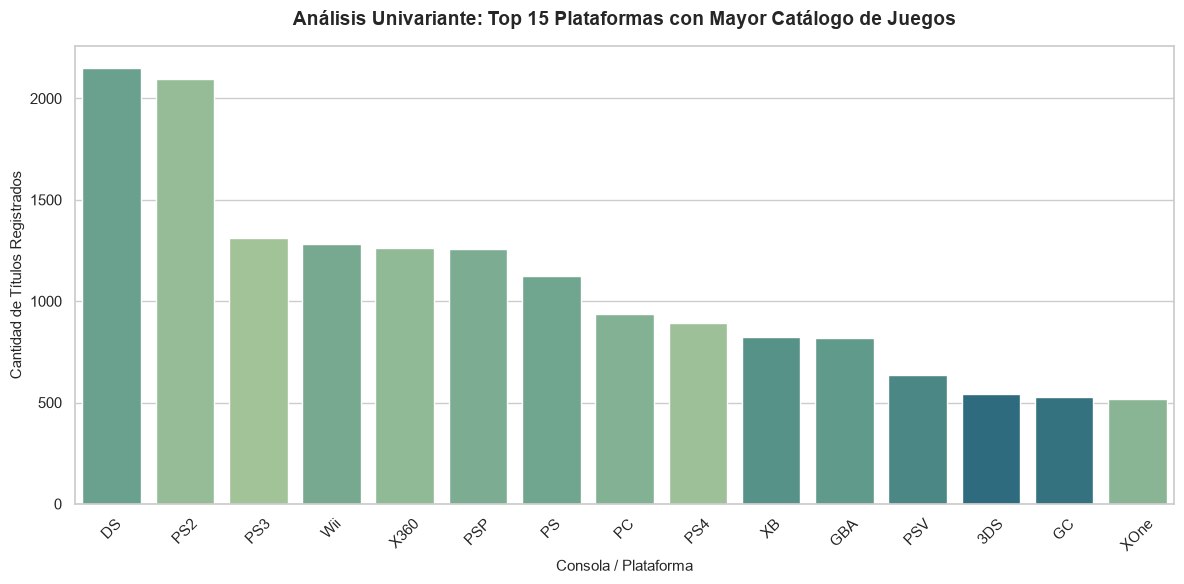

In [13]:
plt.figure(figsize=(12, 6))

# Conteo puro del Top 15 consolas con más juegos en el catálogo
order_consoles = df["console"].value_counts().head(15).index
sns.countplot(
    data=df, x="console", order=order_consoles, palette="crest", hue="console", legend=False
)

plt.title(
    "Análisis Univariante: Top 15 Plataformas con Mayor Catálogo de Juegos",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Consola / Plataforma", fontsize=11)
plt.ylabel("Cantidad de Títulos Registrados", fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 6. Análisis Bivariante.

## Top plataformas por ventas.